# E5b - Anchor-distance robustness sweep (reproducer)

Top-to-bottom reproducer for `docs/experiments/E5b-anchor-distance-design.md`.

Headline metric: **paired conditional adoption** (M1 paired definition, denominator excludes case 4 `base=a=pred`).

Key finding: adoption is **uncertainty-modulated AND plausibility-windowed**.
- Correct-base records show essentially no anchor effect (~0.01-0.10 across all distances).
- Wrong-base records show sharp plausibility-windowed pattern: adoption peaks at S2 [2,5] for VQAv2 and decays to ~0 at S4/S5 in both datasets.

All heavy lifting in `scripts/analyze_e5b_distance.py` - this notebook just invokes it and displays.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))
from analyze_e5b_distance import run
out = run()
summary = out['summary']
print(f"loaded {out['n_records']} records, wrote {out['out_csv']}")

loaded 12000 records, wrote docs/insights/_data/E5b_per_stratum.csv


## Per-cell summary

Rows: (dataset, stratum, base) where base is 'correct' or 'wrong'. `adopt_cond = case2 / (case1+case2+case3)` — fraction of eligible records where the model moved to the anchor.

In [2]:
import pandas as pd
pd.set_option('display.float_format', '{:0.4f}'.format)
summary

,dataset,stratum,stratum_range,stratum_midpoint,base,n_total,case1,case2,case3,case4,n_eligible,n_adopted,adopt_cond,adopt_cond_ci_lo,adopt_cond_ci_hi,adopt_uncond
0,VQAv2,S1,"[0,1]",0.5000,correct,601,348,38,14,201,400,38,0.0950,0.0675,0.1275,0.0632
1,VQAv2,S1,"[0,1]",0.5000,wrong,399,270,43,19,67,332,43,0.1295,0.0934,0.1687,0.1078
2,VQAv2,S2,"[2,5]",3.5000,correct,601,584,17,0,0,601,17,0.0283,0.0166,0.0433,0.0283
3,VQAv2,S2,"[2,5]",3.5000,wrong,399,364,12,3,20,379,12,0.0317,0.0158,0.0501,0.0301
4,VQAv2,S3,"[6,30]",18.0000,correct,601,589,12,0,0,601,12,0.0200,0.0100,0.0316,0.0200
5,VQAv2,S3,"[6,30]",18.0000,wrong,399,395,4,0,0,399,4,0.0100,0.0025,0.0226,0.0100
6,VQAv2,S4,"[31,300]",165.0000,correct,601,591,10,0,0,601,10,0.0166,0.0083,0.0283,0.0166
7,VQAv2,S4,"[31,300]",165.0000,wrong,399,395,4,0,0,399,4,0.0100,0.0000,0.0201,0.0100
8,VQAv2,S5,"[301,inf)",650.0000,correct,601,593,8,0,0,601,8,0.0133,0.0050,0.0233,0.0133
9,VQAv2,S5,"[301,inf)",650.0000,wrong,399,398,1,0,0,399,1,0.0025,0.0000,0.0075,0.0025


## Headline figure - adoption vs distance, base correctness split

Two panels (VQAv2, TallyQA). Each panel has two lines: correct-base (flat) and wrong-base (peaked at S2).

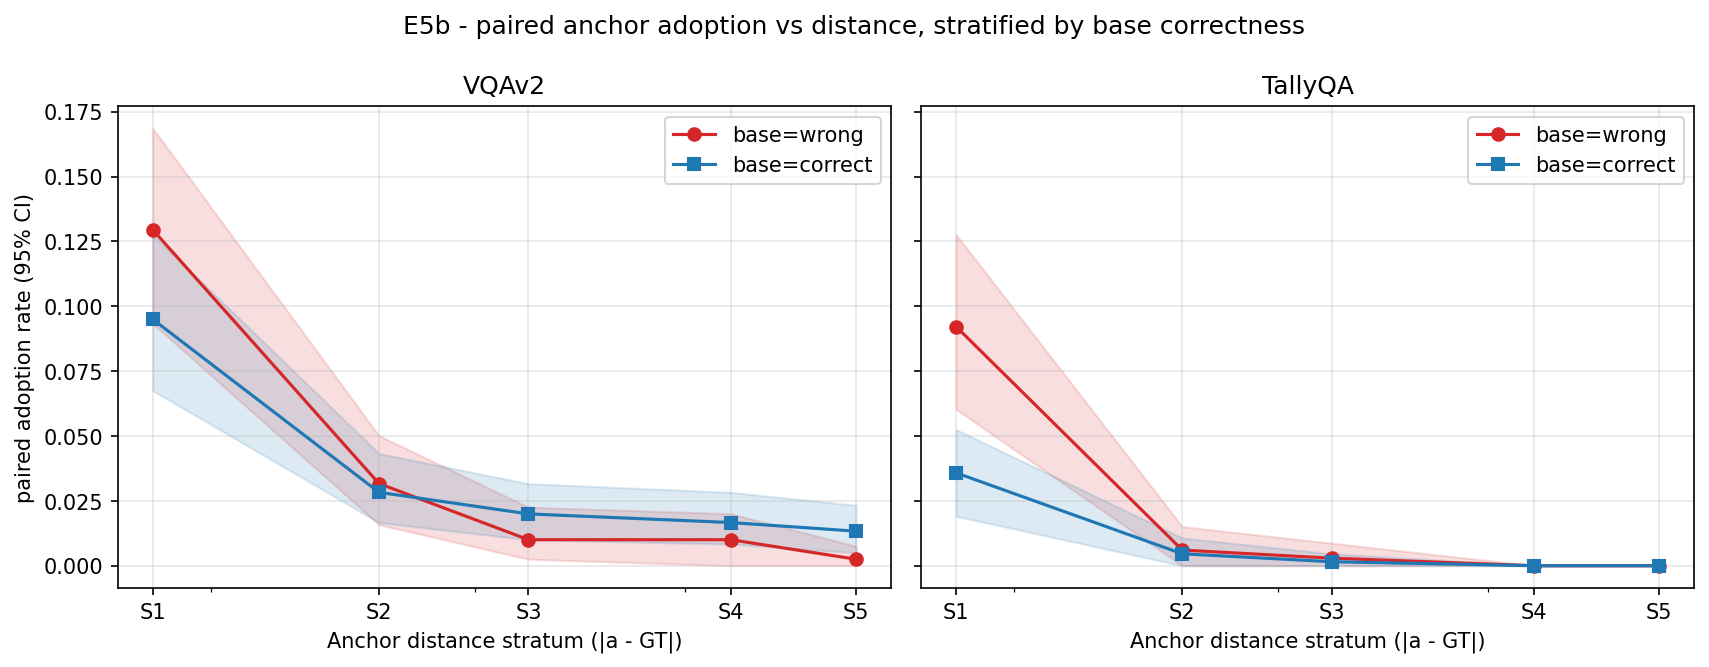

In [3]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5b_adopt_cond_curve.png')))

## Cross-dataset overlay (wrong-base only)

Both datasets show the same plausibility-windowed adoption pattern when the model is uncertain.

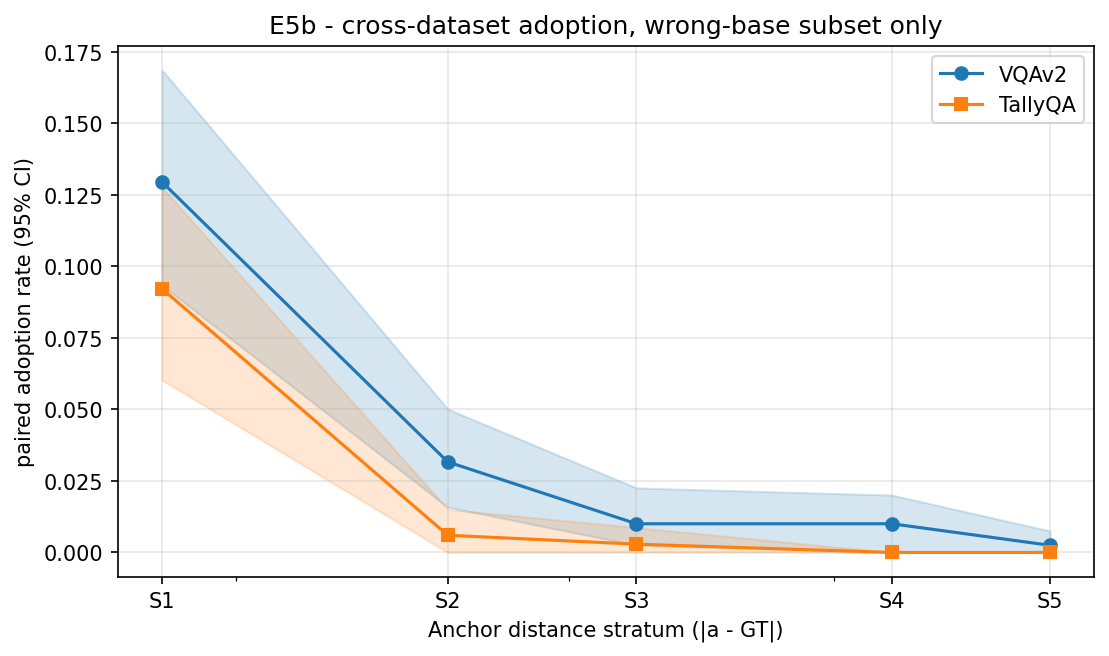

In [4]:
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5b_adopt_cond_overlay.png')))

## Sanity check - wrong-base S1 vs S5 ratio

If plausibility-windowed adoption is real, the wrong-base S1/S2 cells should be much higher than S4/S5.

In [5]:
for ds in ['VQAv2', 'TallyQA']:
    cell = summary[(summary['dataset']==ds) & (summary['base']=='wrong')].set_index('stratum')
    s1 = cell.loc['S1', 'adopt_cond']
    s5 = cell.loc['S5', 'adopt_cond']
    ratio = s1 / s5 if s5 > 0 else float('inf')
    print(f'{ds:<8s} wrong-base adopt_cond: S1={s1:.4f}, S5={s5:.4f}, S1/S5 ratio={ratio:.1f}')

VQAv2    wrong-base adopt_cond: S1=0.1295, S5=0.0025, S1/S5 ratio=51.7
TallyQA  wrong-base adopt_cond: S1=0.0922, S5=0.0000, S1/S5 ratio=inf
